#**Implementation of Support Vector Machine (SVM) using a real dataset (Breast Cancer Dataset)**

**Step 1: Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Step 2: Load Real Dataset**

In [2]:
data = load_breast_cancer()

# data.data: Numerical Value
# data.feature_names: Feature name
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add the target (output) column to the DataFrame
# Target = 0 (Malignant - Cancerous)
# Target = 1 (Benign - Non-cancerous)
df['Target'] = data.target

df.sample(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
339,23.51,24.27,155.10,1747.0,0.10690,0.12830,0.23080,0.14100,0.1797,0.05506,...,30.73,202.40,2906.0,0.1515,0.2678,0.48190,0.20890,0.2593,0.07738,0
79,12.86,18.00,83.19,506.3,0.09934,0.09546,0.03889,0.02315,0.1718,0.05997,...,24.82,91.88,622.1,0.1289,0.2141,0.17310,0.07926,0.2779,0.07918,1
260,20.31,27.06,132.90,1288.0,0.10000,0.10880,0.15190,0.09333,0.1814,0.05572,...,39.16,162.30,1844.0,0.1522,0.2945,0.37880,0.16970,0.3151,0.07999,0
222,10.18,17.53,65.12,313.1,0.10610,0.08502,0.01768,0.01915,0.1910,0.06908,...,22.84,71.94,375.6,0.1406,0.1440,0.06572,0.05575,0.3055,0.08797,1
379,11.08,18.83,73.30,361.6,0.12160,0.21540,0.16890,0.06367,0.2196,0.07950,...,32.82,91.76,508.1,0.2184,0.9379,0.84020,0.25240,0.4154,0.14030,0


In [ ]:
df.shape

(569, 31)

**Step 3: Select Only  Features (For Visualization)**

Decision boundaries can only be drawn in 2D, so we'll use only two features.

In [3]:
X = df[['mean radius', 'mean texture',]]

y = df['Target']

**Step 4: Train-Test Split**

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Step 5: Feature Scaling**

SVM works best when features are scaled.

In [ ]:
# Create an object of the StandardScaler class
scaler = StandardScaler()

# Learn the mean and standard deviation from the training data
# Then transform the training data so that:
# Mean = 0
# Standard Deviation = 1
X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

**Step 6: Train SVM Model**

In [5]:
#svm = SVC(kernel='linear')
#svm = SVC(kernel='rbf')
#svm = SVC(kernel='sigmoid')
svm = SVC(kernel='poly', degree=3)
svm.fit(X_train, y_train)

SVC(kernel='poly')

**Step 7: Prediction**

In [6]:
y_pred = svm.predict(X_test)

In [7]:
y_pred

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0])

**Step 8: Accuracy**

In [8]:
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.9122807017543859


**Step 9: Confusion Matrix**

In [9]:
print(confusion_matrix(y_test, y_pred))

[[38  5]
 [ 5 66]]


**Step 10: Classification Report**

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89        43
           1       0.93      0.94      0.94        71

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.92       114
weighted avg       0.92      0.92      0.92       114



In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully")
print(X_train_scaled.shape)

Scaling completed successfully
(455, 2)


In [14]:
from sklearn.svm import SVC

svm = SVC(
    kernel="linear",
    random_state=42
)

svm.fit(X_train_scaled, y_train)

print("SVM model trained successfully")

SVM model trained successfully


Step 11: Visualize Support Vectors & Decision Boundary

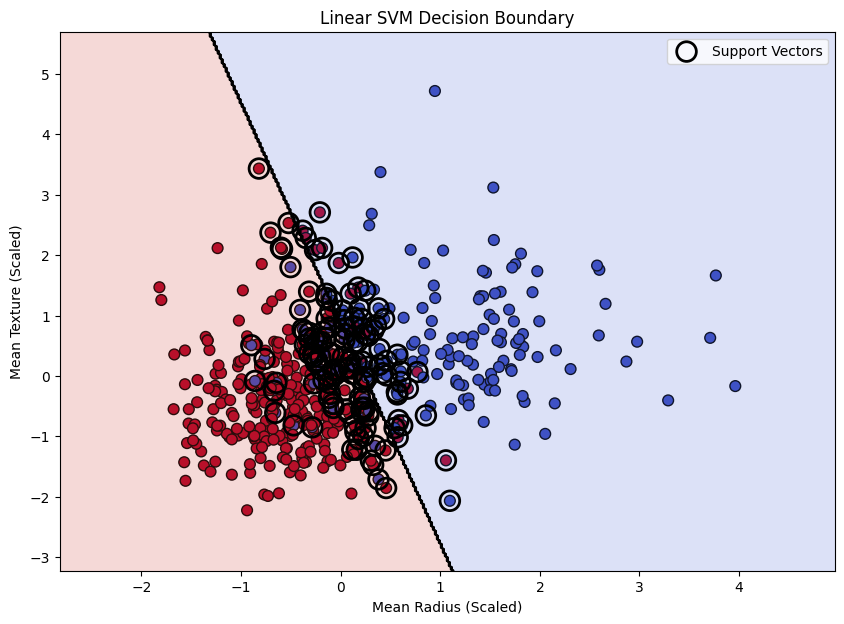

In [15]:
plt.figure(figsize=(10,7))

# Plot data points
plt.scatter(
    X_train_scaled[:,0],
    X_train_scaled[:,1],
    c=y_train,
    cmap='coolwarm',
    edgecolors='k',
    s=60
)

# Create mesh grid
x_min, x_max = X_train_scaled[:,0].min()-1, X_train_scaled[:,0].max()+1
y_min, y_max = X_train_scaled[:,1].min()-1, X_train_scaled[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Decision Boundary
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.2,
    cmap='coolwarm'
)

# Decision Line
plt.contour(
    xx,
    yy,
    Z,
    colors='black',
    linewidths=1
)

# Support Vectors
plt.scatter(
    svm.support_vectors_[:,0],
    svm.support_vectors_[:,1],
    s=200,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support Vectors'
)

plt.xlabel("Mean Radius (Scaled)")
plt.ylabel("Mean Texture (Scaled)")
plt.title("Linear SVM Decision Boundary")

plt.legend()
plt.show()

**Expected Accuracy**

Using the two selected features, a linear SVM typically achieves around 85–92% accuracy. If you use all 30 features from the dataset (without limiting to two for visualization), accuracy is usually 95–99%.

In [16]:
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.9122807017543859
